In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load raw transaction dataset

df = pd.read_csv(
    "../data/raw/transactions.csv"
)

# Display first 5 rows

df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [3]:
# Check dataset dimensions

print("Dataset Shape:", df.shape)

Dataset Shape: (11400, 26)


In [4]:
# Display column names

print(df.columns)

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')


In [5]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [6]:
# Check missing values

missing = df.isnull().sum()

print(missing)

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64


In [7]:
# Percentage missing values

missing_pct = (
    df.isnull().sum() / len(df)
) * 100

missing_pct.sort_values(
    ascending=False
)

amount_usd                   2.675439
ip_address                   2.675439
ip_country                   2.640351
kyc_tier                     2.631579
device_trust_score           2.587719
fee                          2.587719
timestamp                    0.254386
transaction_id               0.000000
customer_id                  0.000000
home_country                 0.000000
channel                      0.000000
amount_src                   0.000000
source_currency              0.000000
dest_currency                0.000000
new_device                   0.000000
device_id                    0.000000
location_mismatch            0.000000
exchange_rate_src_to_dest    0.000000
ip_risk_score                0.000000
account_age_days             0.000000
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud                     0.000000
dtype: float

In [8]:
# Check duplicate rows

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 200


In [9]:
# Check data types

df.dtypes

transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                       str
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [10]:
# Summary statistics

df.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [11]:
# Fraud distribution

print(
    df["is_fraud"].value_counts()
)

is_fraud
0    10403
1      997
Name: count, dtype: int64


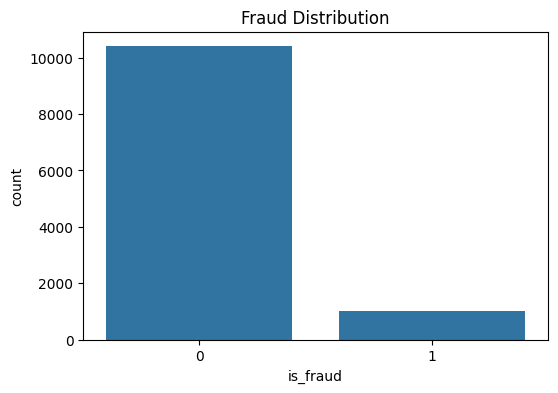

In [12]:
# Visualize fraud distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="is_fraud",
    data=df
)

plt.title(
    "Fraud Distribution"
)

plt.show()

In [13]:
# Source currencies

print(
    df["source_currency"].unique()
)

print(
    df["source_currency"].nunique()
)

<ArrowStringArray>
['USD', 'CAD', 'GBP']
Length: 3, dtype: str
3


## Key Findings

- Dataset contains 11,400 rows and 26 columns.
- Fraud rate is approximately 8.75%.
- Missing values exist in timestamp, amount_usd, fee, ip_country, kyc_tier and device_trust_score.
- 200 duplicate records are present.
- Source currencies are USD, CAD and GBP.
- Data cleaning is required before modelling.